# KNN Exercise

![iris](../assets/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available here.
https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

## Task

1. Please import and preprocess the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance?

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

#### Task 1

Let's first import some libraries, as we will need them later.

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from itertools import combinations
from scipy.stats import zscore

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler

After having unziped the data, and located at successfully in ../data/iris.csv, we can read it into a dataframe:

In [23]:
df = pd.read_csv("../data/iris.csv")

And let's quickly check if the import worked.

In [24]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


On first glance, everything looks fine. Let's check the datatypes and see if we have missing values:

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


This also looks fine: 
- No missing values
- all features are floats (numerical) 
- only the target is an object (=string)

Next, let's quickly have a look at the distribution of the features:

In [26]:
desc = df.describe().T
display(desc)

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


.. as well as the spanned range for each feature and the zscores for the edge-observations (to check for outliers)

In [27]:
desc["range"] = desc["max"] - desc["min"]
desc["zscore_min"] = (desc["mean"] - desc["min"]) / desc["std"]
desc["zscore_max"] = (desc["max"] - desc["mean"]) / desc["std"]
display(desc)

,count,mean,std,min,25%,50%,75%,max,range,zscore_min,zscore_max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,3.6,1.863780,2.483699
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4,2.4,2.430844,3.104284
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9,5.9,1.563497,1.780377
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5,2.4,1.439627,1.705189


We shouldn't run into big issues here, but we could check later if scaling improves things - after all the range of the feature ```petal_length``` is more then twice as large as from the ```xxx_width``` features.

A z-score threshold of 3 is often used for outlier detection. There is at least one observation that could be considered to be an outlier with regards to the ```sepal_width```. Let's identify these 'outliers':


In [28]:
# exclude target column
features = df.columns.drop("species")

# compute z-scores
zscores = pd.DataFrame(
    zscore(df[features]),
    columns=features,
    index=df.index,
)

# identify rows containing at least one outlier
is_outlier = (zscores.abs() > 3)

print("These are the outlier rows:")
outliers = df.loc[is_outlier.any(axis=1)]
display(outliers)

print("These are their z-scores:")
outlier_zscores = zscores.loc[is_outlier.any(axis=1)]
display(outlier_zscores)

These are the outlier rows:


,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,Iris-setosa


These are their z-scores:


,sepal_length,sepal_width,petal_length,petal_width
15,-0.173674,3.114684,-1.284407,-1.050031


So it is only one observation that is only slightly above the threshold. We should be able to keep it.

It seems that this data set is reasonable clean without any preprocessing required.

Next, lets generate some plots to get to a visualisation, inside we can mark the point that was identified as an outlier.

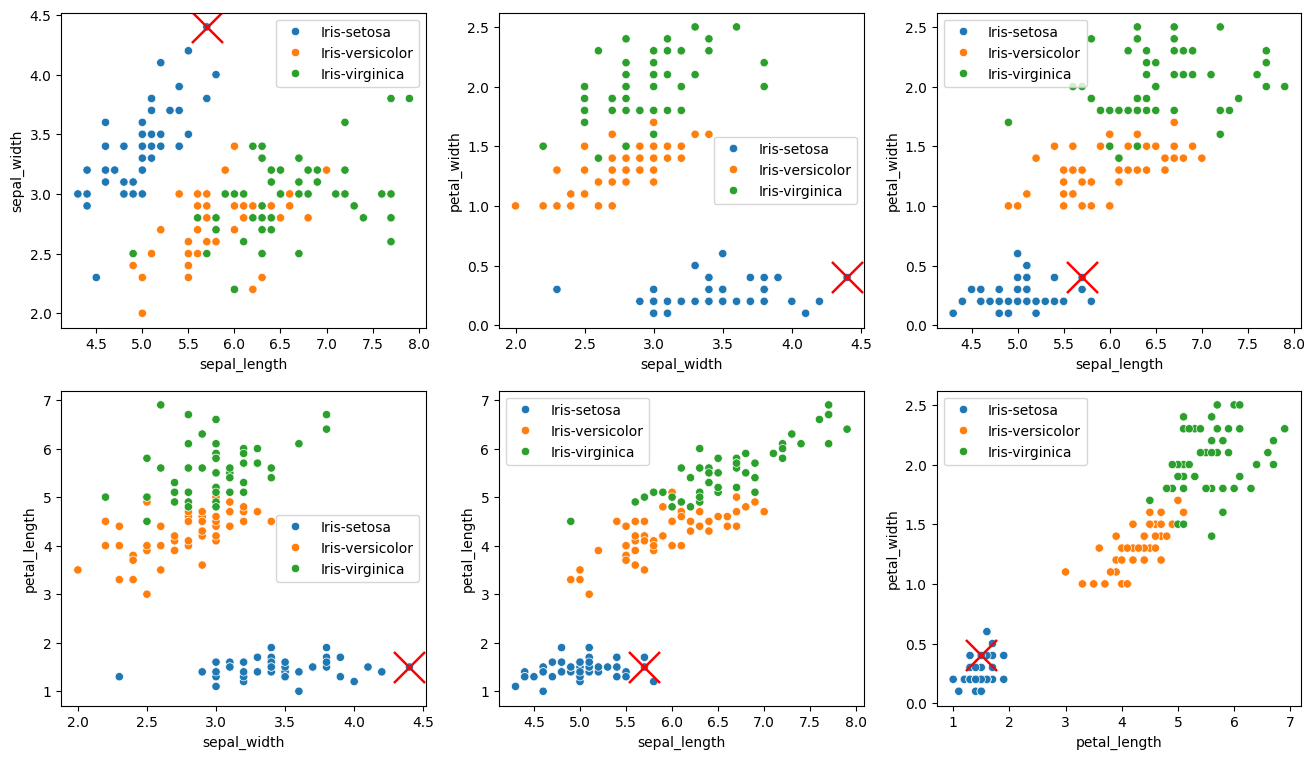

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
ft_combinations = combinations(features, 2)
for i, (f1, f2) in enumerate(ft_combinations):
    sns.scatterplot(data=df, x=f1, y=f2, hue="species", ax=ax[i % 2, i % 3])
    sns.scatterplot(
        data=outliers, x=f1, y=f2, color="red", s=500, marker="x", ax=ax[i % 2, i % 3]
    )

So far so good! Next, let's check the distributions of the features and see how they are correlated. For that we can use a pairplot:

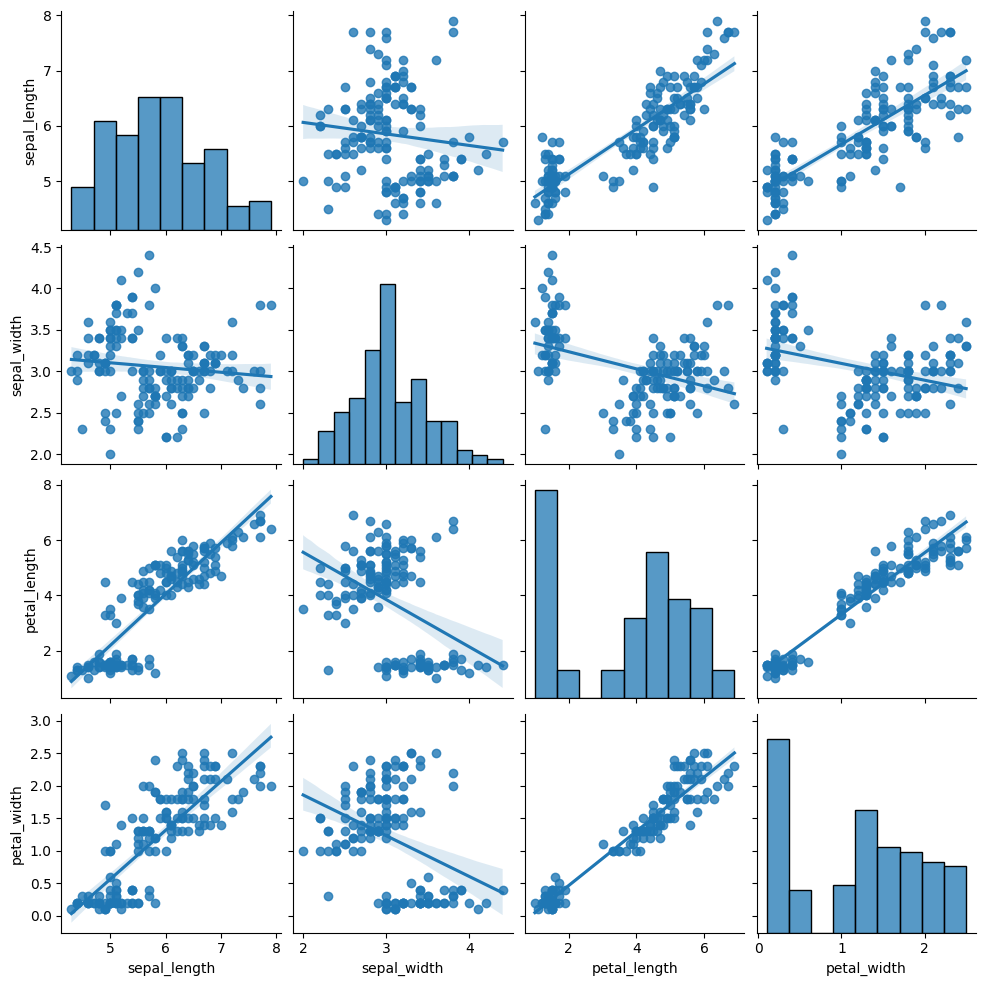

In [30]:
sns.pairplot(df, kind="reg")

```petal_length``` and ```petal_width``` show 2 distinct peaks in their histograms. This indicates overlapping distributions. However, we could already identify from the previous plots, that we would be able to seperate one of the species (```iris_setosa```) just based on one of those features. 

Additionally, we can see, that we have several correlations between the features. Let's check closer:

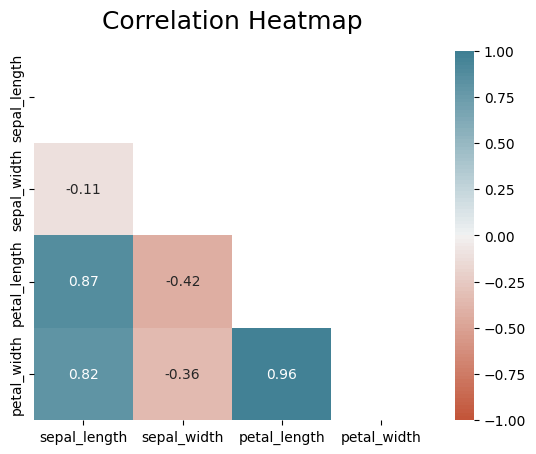

In [31]:
# Create a new DataFrame that only includes the numerical variables
df_numeric = df.select_dtypes(include=["float64", "int64"])

## Upper triangle of an array.
## Return a copy of an array with the elements below the k-th diagonal zeroed
mask = np.triu(np.ones_like(df_numeric.corr(), dtype=bool))

heatmap = sns.heatmap(
    df_numeric.corr(),
    mask=mask,
    vmin=-1,
    vmax=1,
    annot=True,
    cmap=sns.diverging_palette(20, 220, n=100),
)
heatmap.set_title("Correlation Heatmap", fontdict={"fontsize": 18}, pad=16);

#### Modeling

With the EDA done, we can start building a model

In [32]:
# define the target
y = df.species
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: str

The scale of all features is quite similar. To demonstrate the effect of scaling we artificially inflate the scale of sepal_length.

In [33]:
df.sepal_length = df.sepal_length * 10

In [34]:
# define the features
X = df[features]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,51.0,3.5,1.4,0.2
1,49.0,3.0,1.4,0.2
2,47.0,3.2,1.3,0.2
3,46.0,3.1,1.5,0.2
4,50.0,3.6,1.4,0.2


First step of the modelling process is, to do a train-test split. In this case we use an unusual small training fraction, because the dataset is already easily seperable.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=True, stratify=y, train_size=0.5, random_state=123
)

In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((75, 4), (75, 4), (75,), (75,))

Lets Train a KNN Classifier with a starting parameter of 5 neighbors using the euclidean distance as a metric:

In [37]:
clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Classification report:")
print(classification_report(y_test, y_pred))

print("\n\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       0.96      0.96      0.96        25
Iris-versicolor       0.75      0.60      0.67        25
 Iris-virginica       0.70      0.84      0.76        25

       accuracy                           0.80        75
      macro avg       0.80      0.80      0.80        75
   weighted avg       0.80      0.80      0.80        75



Confusion matrix
[[24  1  0]
 [ 1 15  9]
 [ 0  4 21]]


Now let's try scaling and normalisation to check if this has an effect on the classification

In [38]:
std = StandardScaler()
norm = MinMaxScaler()

In [39]:
X_train_norm = norm.fit_transform(X_train)
X_test_norm = norm.transform(X_test)

In [40]:
clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
clf.fit(X_train_norm, y_train)

y_pred = clf.predict(X_test_norm)
print("Classification report:")
print(classification_report(y_test, y_pred))

print("\n\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        25
Iris-versicolor       0.92      0.92      0.92        25
 Iris-virginica       0.92      0.92      0.92        25

       accuracy                           0.95        75
      macro avg       0.95      0.95      0.95        75
   weighted avg       0.95      0.95      0.95        75



Confusion matrix
[[25  0  0]
 [ 0 23  2]
 [ 0  2 23]]


In [41]:
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [42]:
clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
clf.fit(X_train_std, y_train)

y_pred = clf.predict(X_test_std)
print("Classification report:")
print(classification_report(y_test, y_pred))

print("\n\nConfusion matrix")
print(confusion_matrix(y_test, y_pred))

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        25
Iris-versicolor       0.88      0.92      0.90        25
 Iris-virginica       0.92      0.88      0.90        25

       accuracy                           0.93        75
      macro avg       0.93      0.93      0.93        75
   weighted avg       0.93      0.93      0.93        75



Confusion matrix
[[25  0  0]
 [ 0 23  2]
 [ 0  3 22]]


KNN is very sensitive to the scale of data as it relies on computing the distances. For features with a higher scale, the calculated distances can be very high and might produce poor results. It is thus advised to scale the data before running the KNN. This is true for all algorithms that rely on computation of distance. 

#### Task 2

Now let's wrap this into a function that allows us to compute the accuracy for different parameters - i.e. different numbers of neighbors and different orders of the minkovski metric

In [43]:
def fit_predict(k=3, metric_p=2):
    clf = KNeighborsClassifier(n_neighbors=k, p=metric_p)
    clf.fit(X_train, y_train)
    res = clf.score(X_test, y_test)
    return res

Using this function, we can compute the resulting accuracy for different combinations of the neighbors and distance metric

In [44]:
n_neighbors = range(1, 40)
data = pd.DataFrame(index=n_neighbors)

for p in range(1, 4):
    data[f"p={p}"] = [fit_predict(k, p) for k in n_neighbors]
data = data.reset_index()
data = data.rename(columns={"index": "NrNeighbors"})
data.head()

,NrNeighbors,p=1,p=2,p=3
0,1,0.826667,0.826667,0.826667
1,2,0.906667,0.880000,0.866667
2,3,0.880000,0.866667,0.826667
3,4,0.853333,0.826667,0.813333
4,5,0.826667,0.800000,0.800000


In [45]:
data_long = pd.wide_to_long(
    data, ["p="], i="NrNeighbors", j="MinkovskiOrder", sep=""
).reset_index()
data_long = data_long.rename(columns={"p=": "Accuracy"})
data_long.head()

,NrNeighbors,MinkovskiOrder,Accuracy
0,1,1,0.826667
1,2,1,0.906667
2,3,1,0.880000
3,4,1,0.853333
4,5,1,0.826667


The best numbers of neighbors in this case is [3, 2, 2] and the best Minkovski order is [1 2 1].


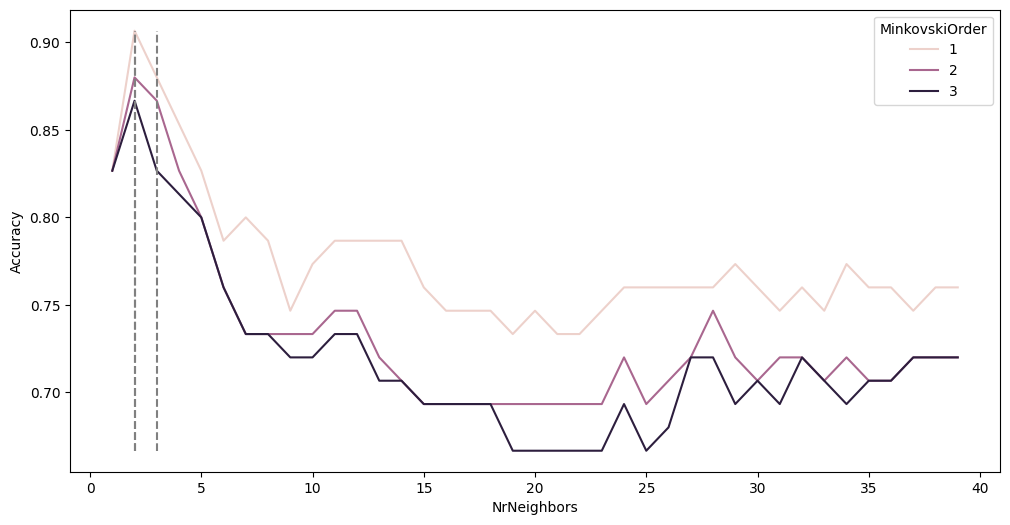

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

highest_accuarcy = np.argsort(data_long.Accuracy)[-3:]
best_k = list(data_long.NrNeighbors[highest_accuarcy])
sns.lineplot(data=data_long, x="NrNeighbors", y="Accuracy", hue="MinkovskiOrder")
ax.vlines(
    best_k,
    data_long.Accuracy.min(),
    data_long.Accuracy.max(),
    colors="grey",
    linestyle="dashed",
)

print(
    f"The best numbers of neighbors in this case is {best_k} and the best Minkovski order is {data_long.MinkovskiOrder[highest_accuarcy].values}."
)